<a href="https://colab.research.google.com/github/Thorfast191/Monocular-Metric-Depth-Estimation/blob/main/MMDE_V1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MOUNT DRIVE

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load CSV

In [7]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [8]:
root = "/content/drive/MyDrive/Datasets/NYU Depth V2/nyu_data"

train_csv = os.path.join(root, "data/nyu2_train.csv")
test_csv  = os.path.join(root, "data/nyu2_test.csv")

train_df = pd.read_csv(train_csv, header=None)
test_df  = pd.read_csv(test_csv, header=None)

train_df.columns = ['image', 'depth']
test_df.columns  = ['image', 'depth']

train_df['image'] = train_df['image'].apply(lambda x: os.path.join(root, x))
train_df['depth'] = train_df['depth'].apply(lambda x: os.path.join(root, x))

test_df['image'] = test_df['image'].apply(lambda x: os.path.join(root, x))
test_df['depth'] = test_df['depth'].apply(lambda x: os.path.join(root, x))

train_sample = train_df.sample(n=1600, random_state=42).reset_index(drop=True)
test_sample  = test_df.sample(n=400, random_state=42).reset_index(drop=True)

print("Train:", len(train_sample), "Test:", len(test_sample))

Train: 1600 Test: 400


# Data Pre-process

In [9]:
def preprocess_sample(img_path, depth_path, size=(224, 224)):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    depth = cv2.imread(depth_path, -1).astype(np.float32)

    # Metric conversion
    depth = (depth - 30.0) / (255.0 - 30.0)
    depth = depth * (10.0 - 0.5) + 0.5

    mask = depth > 0

    img = cv2.resize(img, size)
    depth = cv2.resize(depth, size, interpolation=cv2.INTER_NEAREST)
    mask = cv2.resize(mask.astype(np.float32), size, interpolation=cv2.INTER_NEAREST) > 0

    img = img.astype(np.float32) / 255.0

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    img = (img - mean) / std

    img = torch.from_numpy(img).permute(2,0,1).float()
    depth = torch.from_numpy(depth).float()
    mask = torch.from_numpy(mask).bool()

    return img, depth, mask

In [10]:
train_data, test_data = [], []

for i in tqdm(range(len(train_sample)), desc="Train Prep"):
    train_data.append(preprocess_sample(
        train_sample.iloc[i]['image'],
        train_sample.iloc[i]['depth']
    ))

for i in tqdm(range(len(test_sample)), desc="Test Prep"):
    test_data.append(preprocess_sample(
        test_sample.iloc[i]['image'],
        test_sample.iloc[i]['depth']
    ))

train_imgs   = torch.stack([x[0] for x in train_data])
train_depths = torch.stack([x[1] for x in train_data])
train_masks  = torch.stack([x[2] for x in train_data])

test_imgs   = torch.stack([x[0] for x in test_data])
test_depths = torch.stack([x[1] for x in test_data])
test_masks  = torch.stack([x[2] for x in test_data])

Test Prep: 100%|██████████| 400/400 [13:36<00:00,  2.04s/it]


# Visualization


In [11]:
print("\n===== PREPROCESSING VALIDATION =====")

print("Train Images:", train_imgs.shape)
print("Train Depths:", train_depths.shape)
print("Train Masks :", train_masks.shape)

print("\nDepth Range:")
print("Min:", train_depths.min().item())
print("Max:", train_depths.max().item())

print("\nDepth Stats:")
print("Mean:", train_depths.mean().item())
print("Std :", train_depths.std().item())

valid_ratio = train_masks.float().mean().item()
print("\nValid Depth Ratio:", valid_ratio)

print("\nNaN Check:")
print("Images:", torch.isnan(train_imgs).any().item())
print("Depths:", torch.isnan(train_depths).any().item())


===== PREPROCESSING VALIDATION =====
Train Images: torch.Size([1600, 3, 224, 224])
Train Depths: torch.Size([1600, 224, 224])
Train Masks : torch.Size([1600, 224, 224])

Depth Range:
Min: -0.006666660308837891
Max: 10.0

Depth Stats:
Mean: 2.3693044185638428
Std : 1.6609456539154053

Valid Depth Ratio: 0.9979826807975769

NaN Check:
Images: False
Depths: False


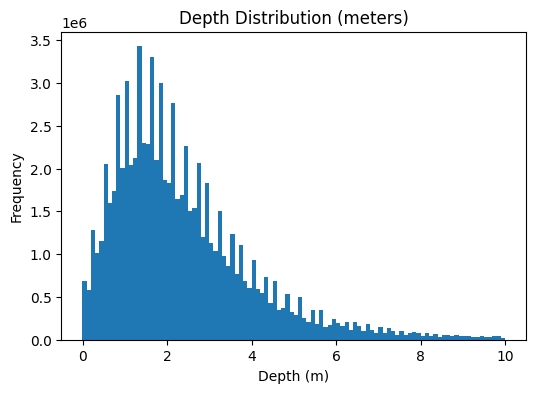

In [12]:
plt.figure(figsize=(6,4))
plt.hist(train_depths.flatten().numpy(), bins=100)
plt.title("Depth Distribution (meters)")
plt.xlabel("Depth (m)")
plt.ylabel("Frequency")
plt.show()

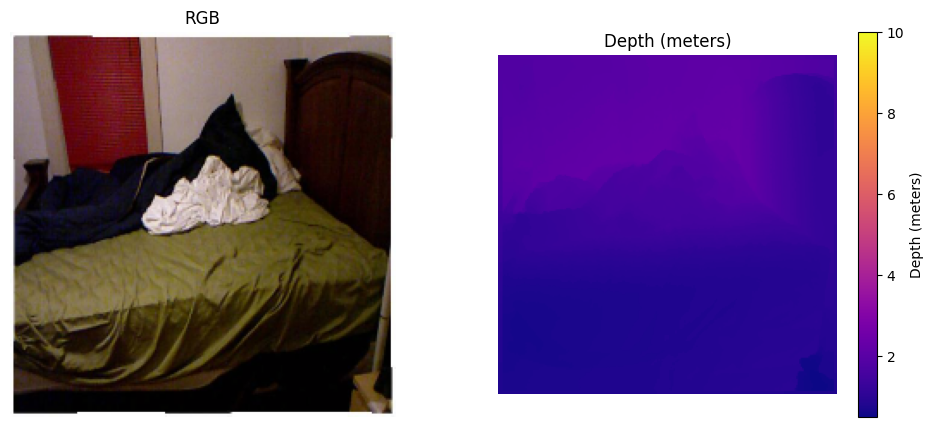

In [13]:
img, depth, mask = train_data[0]

img_vis = img.permute(1,2,0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

img_vis = (img_vis * std) + mean
img_vis = np.clip(img_vis, 0, 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("RGB")
plt.imshow(img_vis)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Depth (meters)")
im = plt.imshow(depth.numpy(), cmap='plasma', vmin=0.5, vmax=10)

cbar = plt.colorbar(im)
cbar.set_label("Depth (meters)")

plt.axis("off")
plt.show()

#  DataLoader

In [14]:
train_loader = DataLoader(
    TensorDataset(train_imgs, train_depths, train_masks),
    batch_size=4,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(test_imgs, test_depths, test_masks),
    batch_size=4
)

#  DPT-Lite Model (timm ViT backbone)

In [19]:
class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip=None):
        x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        if skip is not None:
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class DPTLite(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = timm.create_model(
            'resnet50',
            pretrained=True,
            features_only=True,
            out_indices=(1,2,3,4)
        )

        channels = self.encoder.feature_info.channels()
        self.reduce = nn.ModuleList([nn.Conv2d(ch,256,1) for ch in channels])

        self.up4 = UpBlock(256,256)
        self.up3 = UpBlock(512,256)
        self.up2 = UpBlock(512,128)
        self.up1 = UpBlock(384,64)

        self.out_conv = nn.Conv2d(64,1,1)

    def forward(self, x):
        feats = self.encoder(x)
        feats_reduced = [r(f) for r,f in zip(self.reduce, feats)]
        f1_r, f2_r, f3_r, f4_r = feats_reduced

        x = self.up4(f4_r)

        # Upsample f3_r to match the resolution of x after upsampling in up3
        f3_interp = F.interpolate(f3_r, size=(f3_r.shape[-2]*2, f3_r.shape[-1]*2), mode='bilinear', align_corners=False)
        x = self.up3(x, f3_interp)

        # Upsample f2_r to match the resolution of x after upsampling in up2
        f2_interp = F.interpolate(f2_r, size=(f2_r.shape[-2]*2, f2_r.shape[-1]*2), mode='bilinear', align_corners=False)
        x = self.up2(x, f2_interp)

        # Upsample f1_r to match the resolution of x after upsampling in up1
        f1_interp = F.interpolate(f1_r, size=(f1_r.shape[-2]*2, f1_r.shape[-1]*2), mode='bilinear', align_corners=False)
        x = self.up1(x, f1_interp)

        x = self.out_conv(x)
        x = F.interpolate(x, size=(224,224), mode='bilinear', align_corners=False)

        return torch.exp(x)

# Loss Function (SILog)

In [20]:
def silog_loss(pred, target, mask):
    pred = pred[mask]
    target = target[mask]

    log_diff = torch.log(pred) - torch.log(target)

    return torch.sqrt(
        (log_diff**2).mean() - 0.85*(log_diff.mean()**2)
    )

# Training Loop

In [21]:
model = DPTLite().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

save_dir = "/content/drive/MyDrive/checkpoints/MMDE-V1.0"
os.makedirs(save_dir, exist_ok=True)

ckpt_path = os.path.join(save_dir, "latest.pth")
best_path = os.path.join(save_dir, "best.pth")

start_epoch = 0
best_loss = float("inf")

if os.path.exists(ckpt_path):
    print("🔄 Loading checkpoint...")
    ckpt = torch.load(ckpt_path, map_location=device)

    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])

    start_epoch = ckpt['epoch'] + 1
    print("Resumed from epoch:", start_epoch)

if os.path.exists(best_path):
    best_loss = torch.load(best_path)['loss']

In [22]:
EPOCHS = 10

for epoch in range(start_epoch, EPOCHS):
    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for img, depth, mask in pbar:
        img, depth, mask = img.to(device), depth.to(device), mask.to(device)

        pred = model(img).squeeze(1)
        loss = silog_loss(pred, depth, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}: Avg Loss = {avg_loss:.4f}")

    # Save latest
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, ckpt_path)

    print("💾 Saved latest checkpoint")

    # Save best
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss
        }, best_path)

        print("🏆 Best model updated!")

Epoch 1: 100%|██████████| 400/400 [32:24<00:00,  4.86s/it, loss=0.468]


Epoch 1: Avg Loss = 0.5744
💾 Saved latest checkpoint
🏆 Best model updated!


Epoch 2: 100%|██████████| 400/400 [32:10<00:00,  4.83s/it, loss=0.696]


Epoch 2: Avg Loss = 0.4836
💾 Saved latest checkpoint
🏆 Best model updated!


Epoch 3: 100%|██████████| 400/400 [32:00<00:00,  4.80s/it, loss=0.403]


...

Epoch 8: Avg Loss = 0.3266
💾 Saved latest checkpoint
🏆 Best model updated!


Epoch 9: 100%|██████████| 400/400 [31:06<00:00,  4.67s/it, loss=0.32]


Epoch 9: Avg Loss = 0.3108
💾 Saved latest checkpoint
🏆 Best model updated!


Epoch 10: 100%|██████████| 400/400 [31:00<00:00,  4.65s/it, loss=0.425]


Epoch 10: Avg Loss = 0.2983
💾 Saved latest checkpoint
🏆 Best model updated!


In [23]:
def compute_metrics(pred, target, mask):
    pred = pred[mask]
    target = target[mask]

    pred = torch.clamp(pred, 1e-3, 10)
    target = torch.clamp(target, 1e-3, 10)

    rmse = torch.sqrt(((pred-target)**2).mean())
    abs_rel = torch.mean(torch.abs(pred-target)/target)

    ratio = torch.max(pred/target, target/pred)

    d1 = (ratio < 1.25).float().mean()
    d2 = (ratio < 1.25**2).float().mean()
    d3 = (ratio < 1.25**3).float().mean()

    return rmse.item(), abs_rel.item(), d1.item(), d2.item(), d3.item()


model.eval()

rmse_total, absrel_total = 0, 0
d1_total, d2_total, d3_total = 0, 0, 0
count = 0

with torch.no_grad():
    for img, depth, mask in test_loader:
        img, depth, mask = img.to(device), depth.to(device), mask.to(device)

        pred = model(img).squeeze(1)

        rmse, absrel, d1, d2, d3 = compute_metrics(pred, depth, mask)

        rmse_total += rmse
        absrel_total += absrel
        d1_total += d1
        d2_total += d2
        d3_total += d3
        count += 1

print("\n===== TEST RESULTS =====")
print(f"RMSE   : {rmse_total/count:.4f}")
print(f"AbsRel : {absrel_total/count:.4f}")
print(f"δ1     : {d1_total/count:.4f}")
print(f"δ2     : {d2_total/count:.4f}")
print(f"δ3     : {d3_total/count:.4f}")


===== TEST RESULTS =====
RMSE   : 8.0043
AbsRel : 0.7904
δ1     : 0.0035
δ2     : 0.0099
δ3     : 0.0288


#  Evaluation Metrics

In [24]:
def compute_metrics(pred, target, mask):

    pred = pred[mask]
    target = target[mask]

    # Avoid division issues
    pred = torch.clamp(pred, 1e-3, 10)
    target = torch.clamp(target, 1e-3, 10)

    # RMSE
    rmse = torch.sqrt(((pred - target) ** 2).mean())

    # AbsRel
    abs_rel = torch.mean(torch.abs(pred - target) / target)

    # Delta accuracy
    ratio = torch.max(pred / target, target / pred)

    d1 = (ratio < 1.25).float().mean()
    d2 = (ratio < 1.25**2).float().mean()
    d3 = (ratio < 1.25**3).float().mean()

    return rmse.item(), abs_rel.item(), d1.item(), d2.item(), d3.item()

model.eval()

rmse_total, absrel_total = 0, 0
d1_total, d2_total, d3_total = 0, 0, 0

count = 0

with torch.no_grad():
    for img, depth, mask in test_loader:

        img = img.to(device)
        depth = depth.to(device)
        mask = mask.to(device)

        pred = model(img).squeeze(1)

        rmse, absrel, d1, d2, d3 = compute_metrics(pred, depth, mask)

        rmse_total += rmse
        absrel_total += absrel
        d1_total += d1
        d2_total += d2
        d3_total += d3

        count += 1

print("\n===== TEST RESULTS =====")
print(f"RMSE   : {rmse_total/count:.4f}")
print(f"AbsRel : {absrel_total/count:.4f}")
print(f"δ1     : {d1_total/count:.4f}")
print(f"δ2     : {d2_total/count:.4f}")
print(f"δ3     : {d3_total/count:.4f}")


===== TEST RESULTS =====
RMSE   : 8.0043
AbsRel : 0.7904
δ1     : 0.0035
δ2     : 0.0099
δ3     : 0.0288
